In [1]:
import torch
import torch.multiprocessing as mp
from gymnasium.vector import AsyncVectorEnv
import numpy as np
from env import mbb
from models import ppo
import os
import pandas as pd
import matplotlib.pyplot as plt
import logging
from datetime import datetime
import random
from models import ensemble_ppo


In [2]:

# Configure logging
logging.basicConfig(
    level=logging.INFO,  # Set to DEBUG for more detailed logs
    format='%(asctime)s - %(levelname)s - %(message)s',
    handlers=[
        logging.FileHandler("reward_logs.log"),  # Log to a file
        logging.StreamHandler()  # Also log to console
    ]
)


print("============================================================================================")
device = torch.device('cpu')
if(torch.cuda.is_available()): 
    device = torch.device('cuda:0') 
    torch.cuda.empty_cache()
    print("Device set to : " + str(torch.cuda.get_device_name(device)))
else:
    print("Device set to : cpu")  
print("============================================================================================")


Device set to : NVIDIA GeForce RTX 4070 Laptop GPU


In [3]:


def make_beam_env():
    beam_type = random.choice([1, 2, 3, 4, 4, 4])
    # beam_type = 1
    return mbb.BeamOptimizationEnv(width=6, height=6, density=0.4, step_size=0.05, optimal_density=0.5, reward_weights=None, beam_type = beam_type)

if __name__ == "__main__":
    # Set the start method to 'spawn' to avoid CUDA issues
    mp.set_start_method('spawn', force=True)

    # Hyperparameters
    env_name = "BeamOptimizationEnv"
    env = mbb.BeamOptimizationEnv(width=6, height=6, density=0.4, step_size=0.05, optimal_density=0.5)
    has_continuous_action_space = False
    max_ep_len = env.width * env.height * 10 

    action_std = None  

    
    best_params = {
        'K_epochs': 3,
        'eps_clip': 0.1,
        'gamma': 0.9939332339275259,
        'lr_actor': 0.0007628325751692734,
        'lr_critic': 0.0007
    }
    #''' designed for original mbb_beam
    best_params = {
        'K_epochs': 15,
        'eps_clip': 0.15,
        'gamma': 0.95,
        'lr_actor': 0.00015,
        'lr_critic': 0.00057
    }#'''
   #


    update_timestep = max_ep_len  # Update PPO every 'update_timestep' timesteps

    K_epochs = best_params['K_epochs']
    eps_clip = best_params['eps_clip']
    gamma = best_params['gamma']
    lr_actor = best_params['lr_actor']
    lr_critic = best_params['lr_critic']
    random_seed = 0 
    num_envs = 32
    env_fns = [make_beam_env for _ in range(num_envs)]  # Pass the function itself
    vector_env = AsyncVectorEnv(env_fns)
    print(type(vector_env))
    # Get state and action dimensions
    state_dim = vector_env.single_observation_space.shape[0]
    print(f"State dimension: {state_dim}")

    if has_continuous_action_space:
        action_dim = vector_env.single_action_space.shape[0]
    else:
        action_dim = vector_env.single_action_space.n

    # Initialize PPO agent
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    num_agents = 16  
    envs_per_agent = num_envs // num_agents  

    ensemble_agent = ensemble_ppo.EnsemblePPO(
        num_agents=num_agents,
        state_dim=state_dim,
        action_dim=action_dim,
        has_continuous_action_space=False,
        action_std_init=None,
        lr_actor=lr_actor,
        lr_critic=lr_critic,
        gamma=gamma,
        K_epochs=K_epochs,
        eps_clip=eps_clip,
        gae_lambda=0.95,
        num_envs=envs_per_agent,
        device=device
    )
    # track total training time
    start_time = datetime.now().replace(microsecond=0)
    print("Started training at (GMT) : ", start_time)

    print("============================================================================================")
    ###################### logging ######################

    #### log files for multiple runs are NOT overwritten

    log_dir = "PPO_logs"
    if not os.path.exists(log_dir):
        os.makedirs(log_dir)

    log_dir = log_dir + '/' + env_name + '/'
    if not os.path.exists(log_dir):
        os.makedirs(log_dir)


    #### get number of log files in log directory
    run_num = 0
    current_num_files = next(os.walk(log_dir))[2]
    run_num = len(current_num_files)


    #### create new log file for each run 
    log_f_name = log_dir + '/PPO_' + env_name + "_log_" + str(run_num) + ".csv"

    print("current logging run number for " + env_name + " : ", run_num)
    print("logging at : " + log_f_name)

    #####################################################


    ################### checkpointing ###################

    run_num_pretrained = 0      #### change this to prevent overwriting weights in same env_name folder

    directory = "PPO_preTrained"
    if not os.path.exists(directory):
        os.makedirs(directory)

    directory = directory + '/' + env_name + '/'
    if not os.path.exists(directory):
        os.makedirs(directory)


    checkpoint_path = directory + "PPO_{}_{}_{}.pth".format(env_name, random_seed, run_num_pretrained)
    print("save checkpoint path : " + checkpoint_path)

    #####################################################


    # logging file
    log_f = open(log_f_name,"w+")
    log_f.write('episode,timestep,reward\n')
    print_running_reward = 0
    log_running_reward = 0
    print_running_episodes = 0
    max_ep_len = env.width * env.height * 10 
    max_training_timesteps = int(1e4)  # Total number of training timesteps

    print_freq = max_ep_len  *2      # Print avg reward every 'print_freq' timesteps
    log_freq = max_ep_len *2        # Log avg reward every 'log_freq' timesteps
    save_model_freq = int(2e3) 
    log_running_episodes = 0


    #### Initialize Logging Variables ####
    timestep = 0
    running_reward = 0
    avg_length = 0
    reward_history = []
    i_episode = 0

    #### Training Loop ####   NEED TO IMPLEMENT EARLY STOPPING TO PREVENT OVERFITTING

    while timestep < max_training_timesteps + 1:
        state, info = vector_env.reset()
        ep_reward = np.zeros(num_envs)
        done_flags = np.array([False] * num_envs)

        for t_step in range(1, max_ep_len + 1):
            # Select actions for all agents based on their assigned environments
            actions = []
            logprobs = []
            state_values = []
            for agent_idx, agent in enumerate(ensemble_agent.agents):
                # Determine the range of environments assigned to this agent
                start_env = agent_idx * envs_per_agent
                end_env = start_env + envs_per_agent
                agent_states = state[start_env:end_env]
                agent_actions, agent_logprobs, agent_state_values = agent.select_action(agent_states)
                actions.append(agent_actions)
                logprobs.append(agent_logprobs)
                state_values.append(agent_state_values)

            # Flatten actions for all agents
            flat_actions = np.concatenate(actions)

            # Take actions in all environments
            try:
                states_new, rewards, dones, truncateds, infos = vector_env.step(flat_actions)
            except Exception as e:
                print(f"Error during environment step: {e}")
                break

            # Combine done flags
            dones_combined = np.logical_or(dones, truncateds)

            # Store transitions for each agent
            for agent_idx, agent in enumerate(ensemble_agent.agents):
                start_env = agent_idx * envs_per_agent
                end_env = start_env + envs_per_agent
                agent_states = state[start_env:end_env]
                agent_actions_tensor = torch.LongTensor(actions[agent_idx]).to(agent.device)
                agent_logprobs_tensor = logprobs[agent_idx]
                agent_state_values_tensor = state_values[agent_idx]
                agent_rewards = torch.FloatTensor(rewards[start_env:end_env]).to(agent.device)
                agent_dones = torch.tensor(dones_combined[start_env:end_env], dtype=torch.bool).to(agent.device)

                agent.buffer.store(
                    states=torch.FloatTensor(agent_states).to(agent.device),
                    actions=agent_actions_tensor,
                    logprobs=agent_logprobs_tensor,
                    rewards=agent_rewards,
                    state_values=agent_state_values_tensor,
                    is_terminals=agent_dones
                )
    
            ep_reward += rewards
            state = states_new
            #timestep += num_envs
            timestep +=1  
            # Update PPO agent if enough timesteps have passed

            # update PPO agent

            if timestep % update_timestep == 0:
                ensemble_agent.update()

            # if continuous action space; then decay action std of ouput action distribution
            if has_continuous_action_space and timestep % action_std_decay_freq == 0:
                ensemble_agent.decay_action_std(action_std_decay_rate, min_action_std)

            # log in logging file
            if timestep % log_freq == 0:

                # log average reward till last episode
                log_avg_reward = log_running_reward / log_running_episodes
                log_avg_reward = np.mean(log_avg_reward)
                log_avg_reward = round(log_avg_reward, 4)

                log_f.write('{},{},{}\n'.format(i_episode, timestep, log_avg_reward))
                log_f.flush()

                log_running_reward = 0
                log_running_episodes = 0


            # printing average reward
            if timestep % print_freq == 0:
                # print average reward till last episode
                print_avg_reward = print_running_reward / print_running_episodes
                print_avg_reward = np.mean(print_avg_reward)
                print_avg_reward = round(print_avg_reward, 2)

                print("Episode : {} \t\t Timestep : {} \t\t Average Reward : {}".format(i_episode, timestep, print_avg_reward))

                print_running_reward = 0
                print_running_episodes = 0
                
            # save model weights
            if timestep % save_model_freq == 0:
                print("--------------------------------------------------------------------------------------------")
                print("saving model at : " + checkpoint_path)
                ensemble_agent.save(checkpoint_path)
                print("model saved")
                print("Elapsed Time  : ", datetime.now().replace(microsecond=0) - start_time)
                print("--------------------------------------------------------------------------------------------")
                
            # break; if the episode is over
            if dones_combined.all():
                break

        print_running_reward += ep_reward
        print_running_episodes += 1

        log_running_reward += ep_reward
        log_running_episodes += 1

        i_episode += 1


    log_f.close()
    env.close()




    # print total training time
    print("============================================================================================")
    end_time = datetime.now().replace(microsecond=0)
    print("Started training at (GMT) : ", start_time)
    print("Finished training at (GMT) : ", end_time)
    print("Total training time  : ", end_time - start_time)
    print("============================================================================================")

<class 'gymnasium.vector.async_vector_env.AsyncVectorEnv'>
State dimension: 36
Started training at (GMT) :  2024-12-25 13:33:47
current logging run number for BeamOptimizationEnv :  15
logging at : PPO_logs/BeamOptimizationEnv//PPO_BeamOptimizationEnv_log_15.csv
save checkpoint path : PPO_preTrained/BeamOptimizationEnv/PPO_BeamOptimizationEnv_0_0.pth
Episode : 1 		 Timestep : 720 		 Average Reward : -136.18
Episode : 3 		 Timestep : 1440 		 Average Reward : -136.99
--------------------------------------------------------------------------------------------
saving model at : PPO_preTrained/BeamOptimizationEnv/PPO_BeamOptimizationEnv_0_0.pth
model saved
Elapsed Time  :  0:00:39
--------------------------------------------------------------------------------------------
Episode : 5 		 Timestep : 2160 		 Average Reward : -136.61
Episode : 7 		 Timestep : 2880 		 Average Reward : -134.5
Episode : 9 		 Timestep : 3600 		 Average Reward : -134.23
----------------------------------------------

 state dim is 36
 action dim is 72
loading network from : PPO_preTrained/BeamOptimizationEnv/PPO_BeamOptimizationEnv_0_0.pth
Agent 0 loaded successfully.
Agent 1 loaded successfully.
Agent 2 loaded successfully.
Agent 3 loaded successfully.
Agent 4 loaded successfully.
Agent 5 loaded successfully.
Agent 6 loaded successfully.
Agent 7 loaded successfully.
Agent 8 loaded successfully.
Agent 9 loaded successfully.
Agent 10 loaded successfully.
Agent 11 loaded successfully.
Agent 12 loaded successfully.
Agent 13 loaded successfully.
Agent 14 loaded successfully.
Agent 15 loaded successfully.
--------------------------------------------------------------------------------------------


2024-12-25 13:49:06,408 - INFO - Episode done: Step: 360 | Action: [49] | Raw Reward: -4.24 | Scaled Reward: -0.8092 | Reward Compliance: -4.64 | Reward Density High: 0.06 | Reward Density Low: 0.06 | Reward Total Mass: -0.00 | Reward Entropy: 0.28 | Total Reward: -0.4315 | Compliance: 463.57 | Constraint: 0.46


number of changed cells in the episode is 360
Episode: 1 		 Reward: -126.08


2024-12-25 13:49:10,831 - INFO - Episode done: Step: 360 | Action: [12] | Raw Reward: -1.14 | Scaled Reward: -0.5322 | Reward Compliance: -1.54 | Reward Density High: 0.07 | Reward Density Low: 0.07 | Reward Total Mass: -0.00 | Reward Entropy: 0.27 | Total Reward: -0.3253 | Compliance: 153.91 | Constraint: 0.50


number of changed cells in the episode is 360
Episode: 2 		 Reward: -114.45


...

2024-12-25 13:49:39,914 - INFO - Episode done: Step: 360 | Action: [12] | Raw Reward: -1.81 | Scaled Reward: -0.6443 | Reward Compliance: -2.20 | Reward Density High: 0.06 | Reward Density Low: 0.06 | Reward Total Mass: -0.00 | Reward Entropy: 0.27 | Total Reward: -0.3728 | Compliance: 220.49 | Constraint: 0.45


number of changed cells in the episode is 360
Episode: 9 		 Reward: -118.58


2024-12-25 13:49:44,125 - INFO - Episode done: Step: 360 | Action: [31] | Raw Reward: -8.48 | Scaled Reward: -0.8946 | Reward Compliance: -8.89 | Reward Density High: 0.07 | Reward Density Low: 0.07 | Reward Total Mass: -0.00 | Reward Entropy: 0.26 | Total Reward: -0.4579 | Compliance: 888.56 | Constraint: 0.49


number of changed cells in the episode is 360
Episode: 10 		 Reward: -139.64
average test reward : -126.19
loading data from : PPO_logs/BeamOptimizationEnv//PPO_BeamOptimizationEnv_log_0.csv
data shape :  (31, 3)
--------------------------------------------------------------------------------------------
loading data from : PPO_logs/BeamOptimizationEnv//PPO_BeamOptimizationEnv_log_1.csv
data shape :  (31, 3)
--------------------------------------------------------------------------------------------
loading data from : PPO_logs/BeamOptimizationEnv//PPO_BeamOptimizationEnv_log_2.csv
data shape :  (313, 3)
--------------------------------------------------------------------------------------------
loading data from : PPO_logs/BeamOptimizationEnv//PPO_BeamOptimizationEnv_log_3.csv
data shape :  (139, 3)
--------------------------------------------------------------------------------------------
loading data from : PPO_logs/BeamOptimizationEnv//PPO_BeamOptimizationEnv_log_4.csv
data shape 

/tmp/ipykernel_20332/3098829805.py:180: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_concat = pd.concat(all_runs)


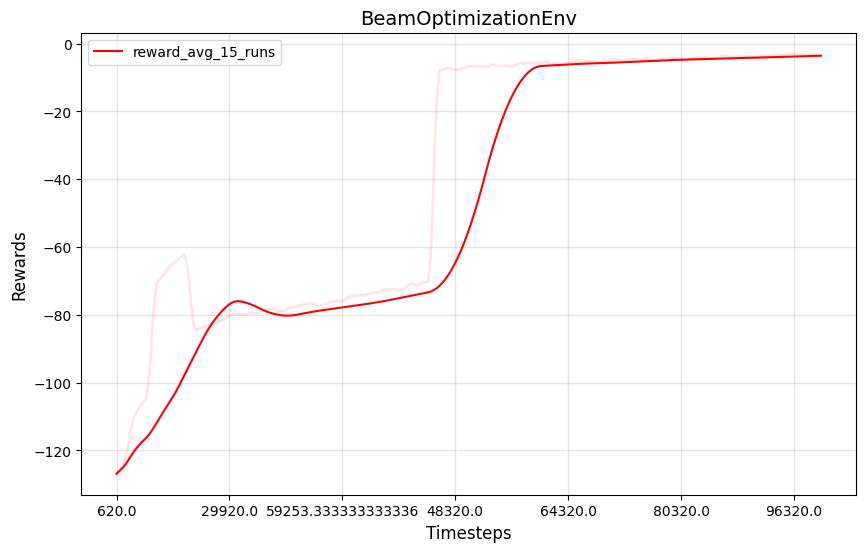

/home/mihovil/mihovil/structural_optimization/src/models/ppo.py:352: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path, map_location=devi

Loading network from: PPO_preTrained/BeamOptimizationEnv/PPO_BeamOptimizationEnv_0_0.pth
Agent 0 loaded successfully.
Agent 1 loaded successfully.
Agent 2 loaded successfully.
Agent 3 loaded successfully.
Agent 4 loaded successfully.
Agent 5 loaded successfully.
Agent 6 loaded successfully.
Agent 7 loaded successfully.
Agent 8 loaded successfully.
Agent 9 loaded successfully.
Agent 10 loaded successfully.
Agent 11 loaded successfully.
Agent 12 loaded successfully.
Agent 13 loaded successfully.
Agent 14 loaded successfully.
Agent 15 loaded successfully.


2024-12-25 13:49:48,480 - INFO - Episode done: Step: 360 | Action: [33] | Raw Reward: -2.61 | Scaled Reward: -0.7233 | Reward Compliance: -1.86 | Reward Density High: 0.06 | Reward Density Low: 0.06 | Reward Total Mass: -1.15 | Reward Entropy: 0.28 | Total Reward: -0.4024 | Compliance: 186.23 | Constraint: 0.53


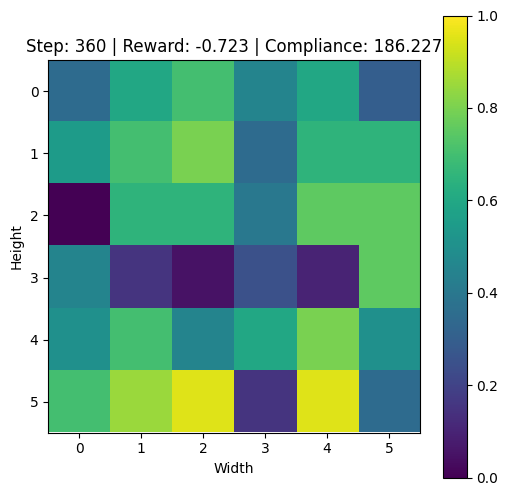

Episode: 0 		 Reward: -121.69


2024-12-25 13:49:52,653 - INFO - Episode done: Step: 360 | Action: [69] | Raw Reward: -10111110.97 | Scaled Reward: -1.0000 | Reward Compliance: -10111111.38 | Reward Density High: 0.08 | Reward Density Low: 0.08 | Reward Total Mass: -0.00 | Reward Entropy: 0.24 | Total Reward: -0.4872 | Compliance: 1011111137.76 | Constraint: 0.49


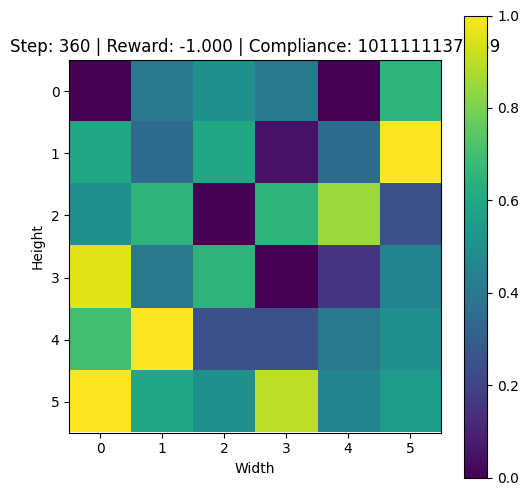

Episode: 1 		 Reward: -154.67


2024-12-25 13:49:56,812 - INFO - Episode done: Step: 360 | Action: [1] | Raw Reward: -2.35 | Scaled Reward: -0.7017 | Reward Compliance: -2.75 | Reward Density High: 0.06 | Reward Density Low: 0.06 | Reward Total Mass: -0.00 | Reward Entropy: 0.28 | Total Reward: -0.3945 | Compliance: 274.87 | Constraint: 0.49


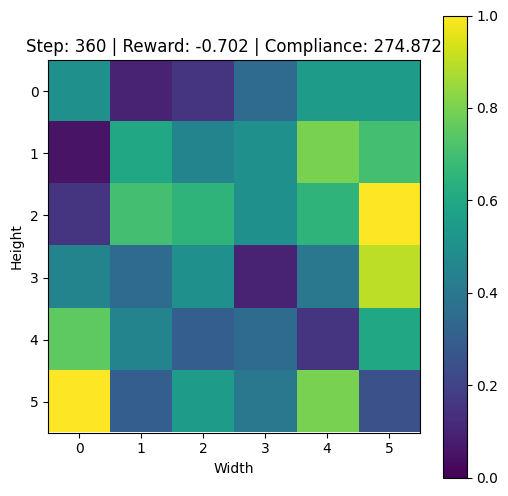

Episode: 2 		 Reward: -123.36


2024-12-25 13:50:01,025 - INFO - Episode done: Step: 360 | Action: [17] | Raw Reward: -3.17 | Scaled Reward: -0.7604 | Reward Compliance: -2.46 | Reward Density High: 0.05 | Reward Density Low: 0.05 | Reward Total Mass: -1.10 | Reward Entropy: 0.28 | Total Reward: -0.4153 | Compliance: 246.09 | Constraint: 0.53


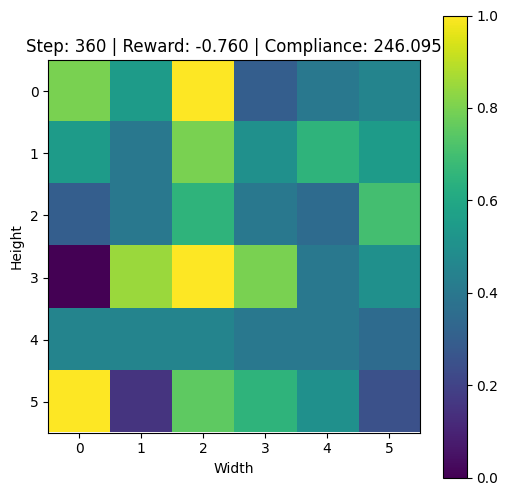

Episode: 3 		 Reward: -128.2


2024-12-25 13:50:05,234 - INFO - Episode done: Step: 360 | Action: [60] | Raw Reward: -1.72 | Scaled Reward: -0.6323 | Reward Compliance: -1.31 | Reward Density High: 0.06 | Reward Density Low: 0.06 | Reward Total Mass: -0.80 | Reward Entropy: 0.28 | Total Reward: -0.3680 | Compliance: 131.23 | Constraint: 0.52


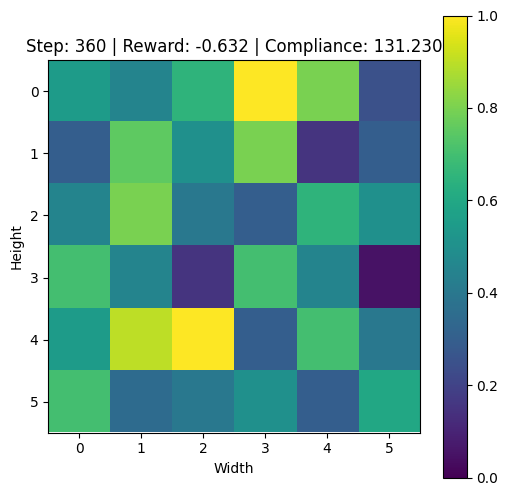

Episode: 4 		 Reward: -121.39


2024-12-25 13:50:09,375 - INFO - Episode done: Step: 360 | Action: [63] | Raw Reward: -3.57 | Scaled Reward: -0.7813 | Reward Compliance: -3.03 | Reward Density High: 0.08 | Reward Density Low: 0.08 | Reward Total Mass: -0.96 | Reward Entropy: 0.24 | Total Reward: -0.4685 | Compliance: 302.71 | Constraint: 0.53


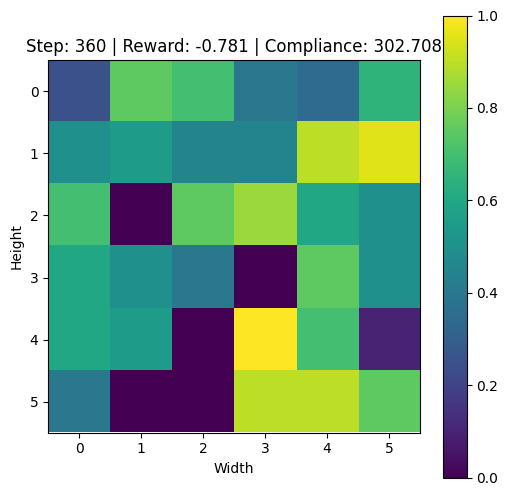

Episode: 5 		 Reward: -125.07


2024-12-25 13:50:13,607 - INFO - Episode done: Step: 360 | Action: [22] | Raw Reward: -1.55 | Scaled Reward: -0.6073 | Reward Compliance: -1.95 | Reward Density High: 0.07 | Reward Density Low: 0.07 | Reward Total Mass: -0.00 | Reward Entropy: 0.26 | Total Reward: -0.3579 | Compliance: 194.89 | Constraint: 0.44


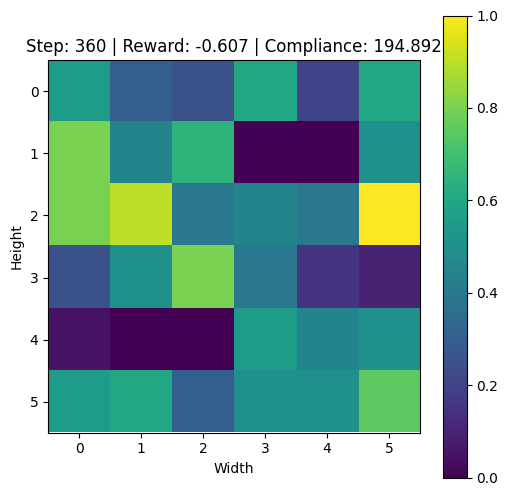

Episode: 6 		 Reward: -103.0


2024-12-25 13:50:17,756 - INFO - Episode done: Step: 360 | Action: [47] | Raw Reward: -3.25 | Scaled Reward: -0.7646 | Reward Compliance: -1.26 | Reward Density High: 0.09 | Reward Density Low: 0.09 | Reward Total Mass: -2.40 | Reward Entropy: 0.24 | Total Reward: -0.4168 | Compliance: 125.79 | Constraint: 0.57


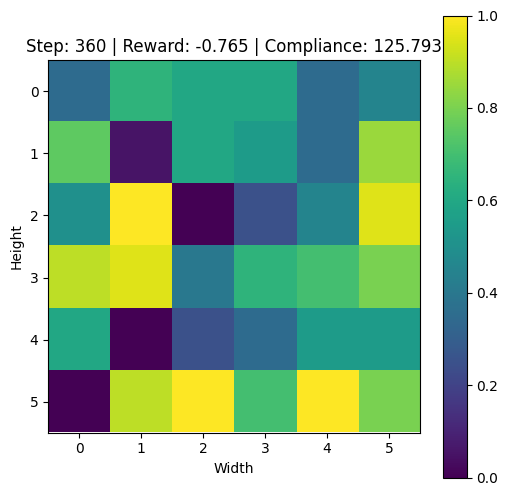

Episode: 7 		 Reward: -129.95


2024-12-25 13:50:21,911 - INFO - Episode done: Step: 360 | Action: [54] | Raw Reward: -7.24 | Scaled Reward: -0.8786 | Reward Compliance: -7.63 | Reward Density High: 0.06 | Reward Density Low: 0.06 | Reward Total Mass: -0.00 | Reward Entropy: 0.28 | Total Reward: -0.4531 | Compliance: 762.63 | Constraint: 0.48


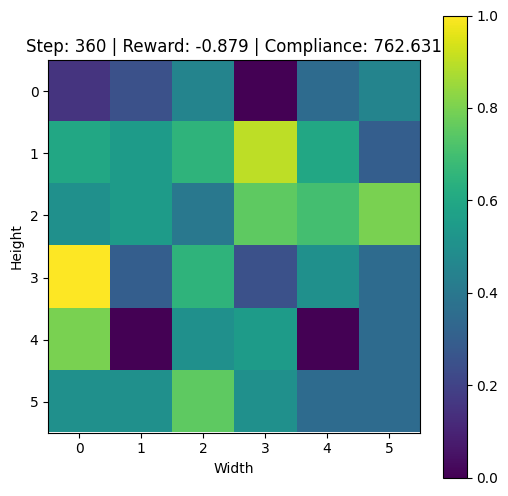

Episode: 8 		 Reward: -124.81


2024-12-25 13:50:26,269 - INFO - Episode done: Step: 360 | Action: [6] | Raw Reward: -4.64 | Scaled Reward: -0.8228 | Reward Compliance: -5.04 | Reward Density High: 0.06 | Reward Density Low: 0.06 | Reward Total Mass: -0.00 | Reward Entropy: 0.28 | Total Reward: -0.4359 | Compliance: 503.97 | Constraint: 0.49


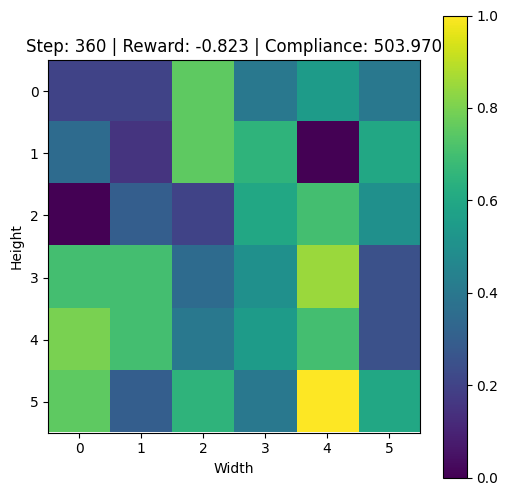

Episode: 9 		 Reward: -117.73


2024-12-25 13:50:30,236 - INFO - Episode done: Step: 360 | Action: [22] | Raw Reward: -1.23 | Scaled Reward: -0.5514 | Reward Compliance: -1.64 | Reward Density High: 0.08 | Reward Density Low: 0.08 | Reward Total Mass: -0.00 | Reward Entropy: 0.25 | Total Reward: -0.3339 | Compliance: 163.82 | Constraint: 0.48


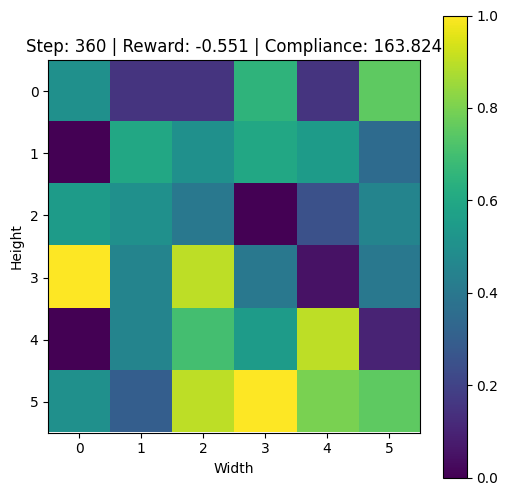

Episode: 10 		 Reward: -114.78


2024-12-25 13:50:34,269 - INFO - Episode done: Step: 360 | Action: [34] | Raw Reward: -1.72 | Scaled Reward: -0.6330 | Reward Compliance: -2.12 | Reward Density High: 0.05 | Reward Density Low: 0.05 | Reward Total Mass: -0.00 | Reward Entropy: 0.28 | Total Reward: -0.3683 | Compliance: 211.77 | Constraint: 0.46


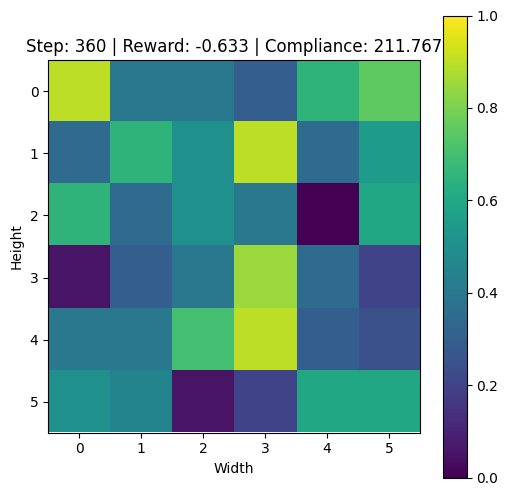

Episode: 11 		 Reward: -107.59


2024-12-25 13:50:38,327 - INFO - Episode done: Step: 360 | Action: [19] | Raw Reward: -1.95 | Scaled Reward: -0.6605 | Reward Compliance: -2.32 | Reward Density High: 0.03 | Reward Density Low: 0.03 | Reward Total Mass: -0.00 | Reward Entropy: 0.31 | Total Reward: -0.3791 | Compliance: 232.03 | Constraint: 0.47


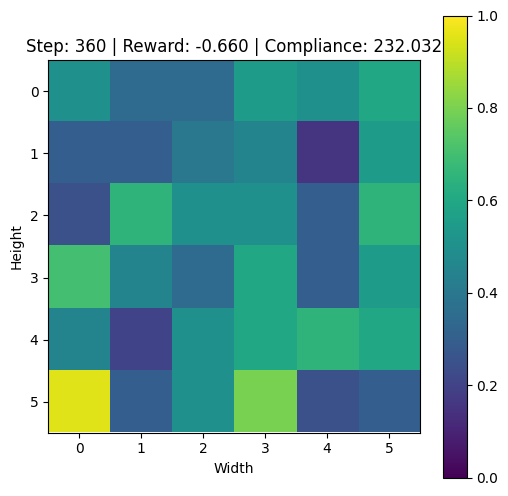

Episode: 12 		 Reward: -108.27


2024-12-25 13:50:42,418 - INFO - Episode done: Step: 360 | Action: [16] | Raw Reward: -25.59 | Scaled Reward: -0.9624 | Reward Compliance: -25.18 | Reward Density High: 0.06 | Reward Density Low: 0.06 | Reward Total Mass: -0.80 | Reward Entropy: 0.28 | Total Reward: -0.4771 | Compliance: 2518.06 | Constraint: 0.52


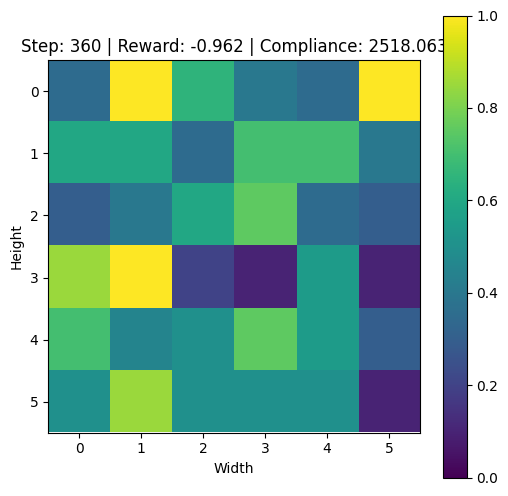

Episode: 13 		 Reward: -141.89


2024-12-25 13:50:46,488 - INFO - Episode done: Step: 360 | Action: [4] | Raw Reward: -1.53 | Scaled Reward: -0.6042 | Reward Compliance: -1.92 | Reward Density High: 0.06 | Reward Density Low: 0.06 | Reward Total Mass: -0.00 | Reward Entropy: 0.28 | Total Reward: -0.3566 | Compliance: 191.87 | Constraint: 0.49


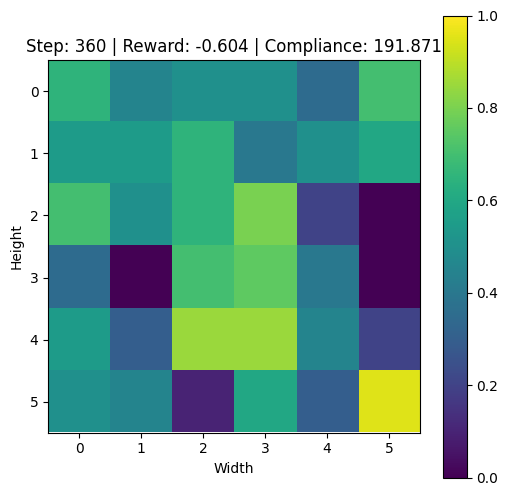

Episode: 14 		 Reward: -110.82
Average test reward: -183.32


In [10]:


print("============================================================================================")


#################################### Testing ###################################


################## hyperparameters ##################

env_name = "BeamOptimizationEnv"
has_continuous_action_space = False
max_ep_len = 1000
action_std = None




total_test_episodes = 10    # total num of testing episodes


K_epochs = best_params['K_epochs']
eps_clip = best_params['eps_clip']
gamma = best_params['gamma']
lr_actor = best_params['lr_actor']
lr_critic = best_params['lr_critic']

#####################################################


env = mbb.BeamOptimizationEnv(width=6, height=6, beam_type=1)

state_dim = env.observation_space.shape[0]
print(f" state dim is {state_dim}")

if has_continuous_action_space:
    action_dim = env.action_space.shape[0]
else:
    action_dim = env.action_space.n
print(f" action dim is {action_dim}")


ppo_kwargs = {
    'state_dim': state_dim,
    'action_dim': action_dim,
    'has_continuous_action_space': has_continuous_action_space,
    'action_std_init': action_std,
    'lr_actor': best_params['lr_actor'],
    'lr_critic': best_params['lr_critic'],
    'gamma': best_params['gamma'],
    'K_epochs': best_params['K_epochs'],
    'eps_clip': best_params['eps_clip'],
    'gae_lambda': 0.95,
    'num_envs': 1,  
    'device': device
}

# Initialize EnsemblePPO
ensemble_agent = ensemble_ppo.EnsemblePPO(
    num_agents=num_agents,
    **ppo_kwargs
)

# preTrained weights directory

random_seed = 0             
run_num_pretrained = 0      


directory = "PPO_preTrained" + '/' + env_name + '/'
checkpoint_path = directory + "PPO_{}_{}_{}.pth".format(env_name, random_seed, run_num_pretrained)
print("loading network from : " + checkpoint_path)

ensemble_agent.load(checkpoint_path)

print("--------------------------------------------------------------------------------------------")



test_running_reward = 0

for ep in range(1, total_test_episodes+1):
    ep_reward = 0
    state,_ = env.reset()

    for t in range(1, max_ep_len+1):
        state = state.reshape(1, -1)  # Shape: (1, state_dim)

        action,_,_ = ensemble_agent.select_action(state)
        if( len(action) >1):
            action = action[0]
        state, reward, done, truncated, info = env.step(action)
        ep_reward += reward
        
        if done:
            print(f"number of changed cells in the episode is {info['num_of_changed_cells']}")
            break

    # clear buffer    
    for agent in ensemble_agent.agents:
        agent.buffer.clear()

    test_running_reward +=  ep_reward
    print('Episode: {} \t\t Reward: {}'.format(ep, round(ep_reward, 2)))
    ep_reward = 0

env.close()


print("============================================================================================")

avg_test_reward = test_running_reward / total_test_episodes
avg_test_reward = round(avg_test_reward, 2)
print("average test reward : " + str(avg_test_reward))

print("============================================================================================")

import os
import pandas as pd
import matplotlib.pyplot as plt

print("============================================================================================")

env_name = 'BeamOptimizationEnv'

fig_num = 0     #### change this to prevent overwriting figures in same env_name folder

plot_avg = True    # plot average of all runs; else plot all runs separately

fig_width = 10
fig_height = 6

# smooth out rewards to get a smooth and a less smooth (var) plot lines
window_len_smooth = 50
min_window_len_smooth = 1
linewidth_smooth = 1.5
alpha_smooth = 1

window_len_var = 5
min_window_len_var = 1
linewidth_var = 2
alpha_var = 0.1

colors = ['red', 'blue', 'green', 'orange', 'purple', 'olive', 'brown', 'magenta', 'cyan', 'crimson', 'gray', 'black']

# make directory for saving figures
figures_dir = "PPO_figs"
if not os.path.exists(figures_dir):
    os.makedirs(figures_dir)

# make environment directory for saving figures
figures_dir = figures_dir + '/' + env_name + '/'
if not os.path.exists(figures_dir):
    os.makedirs(figures_dir)

fig_save_path = figures_dir + '/PPO_' + env_name + '_fig_' + str(fig_num) + '.png'

# get number of log files in directory
log_dir = "PPO_logs" + '/' + env_name + '/'
current_num_files = next(os.walk(log_dir))[2]
num_runs = len(current_num_files)

all_runs = []

for run_num in range(num_runs):
    log_f_name = log_dir + '/PPO_' + env_name + "_log_" + str(run_num) + ".csv"
    print("loading data from : " + log_f_name)
    if os.path.getsize(log_f_name) > 0:  
        data = pd.read_csv(log_f_name)
        data = pd.DataFrame(data)
        print("data shape : ", data.shape)
        all_runs.append(data)
    else:
        print(f"File {log_f_name} is empty. Skipping.")
    print("--------------------------------------------------------------------------------------------")

ax = plt.gca()

if plot_avg:
    # average all runs
    if all_runs:
        df_concat = pd.concat(all_runs)
        df_concat_groupby = df_concat.groupby(df_concat.index)
        data_avg = df_concat_groupby.mean()

        # smooth out rewards to get a smooth and a less smooth (var) plot lines
        data_avg['reward_smooth'] = data_avg['reward'].rolling(window=window_len_smooth, win_type='triang', min_periods=min_window_len_smooth).mean()
        data_avg['reward_var'] = data_avg['reward'].rolling(window=window_len_var, win_type='triang', min_periods=min_window_len_var).mean()

        data_avg.plot(kind='line', x='timestep', y='reward_smooth', ax=ax, color=colors[0], linewidth=linewidth_smooth, alpha=alpha_smooth)
        data_avg.plot(kind='line', x='timestep', y='reward_var', ax=ax, color=colors[0], linewidth=linewidth_var, alpha=alpha_var)

        # keep only reward_smooth in the legend and rename it
        handles, labels = ax.get_legend_handles_labels()
        ax.legend([handles[0]], ["reward_avg_" + str(len(all_runs)) + "_runs"], loc=2)
    else:
        print("No data available to plot.")
else:
    for i, run in enumerate(all_runs):
        
        run['reward_smooth_' + str(i)] = run['reward'].rolling(window=window_len_smooth, win_type='triang', min_periods=min_window_len_smooth).mean()
        run['reward_var_' + str(i)] = run['reward'].rolling(window=window_len_var, win_type='triang', min_periods=min_window_len_var).mean()


        run.plot(kind='line', x='timestep', y='reward_smooth_' + str(i), ax=ax, color=colors[i % len(colors)], linewidth=linewidth_smooth, alpha=alpha_smooth)
        run.plot(kind='line', x='timestep', y='reward_var_' + str(i), ax=ax, color=colors[i % len(colors)], linewidth=linewidth_var, alpha=alpha_var)

    handles, labels = ax.get_legend_handles_labels()
    new_handles = []
    new_labels = []
    for i in range(len(handles)):
        if i % 2 == 0:
            new_handles.append(handles[i])
            new_labels.append(labels[i])
    ax.legend(new_handles, new_labels, loc=2)

# ax.set_yticks(np.arange(0, 1800, 200))
# ax.set_xticks(np.arange(0, int(4e6), int(5e5)))

ax.grid(color='gray', linestyle='-', linewidth=1, alpha=0.2)

ax.set_xlabel("Timesteps", fontsize=12)
ax.set_ylabel("Rewards", fontsize=12)

plt.title(env_name, fontsize=14)

fig = plt.gcf()
fig.set_size_inches(fig_width, fig_height)

print("============================================================================================")

plt.savefig(fig_save_path)
print("figure saved at : ", fig_save_path)

print("============================================================================================")

plt.show()




# Hyperparameters for inference
env_name = "BeamOptimizationEnv"
has_continuous_action_space = False
max_ep_len = 1000
total_inference_episodes = 10  # Total number of inference episodes

# Initialize environment
# env = mbb.BeamOptimizationEnv(width=4, height=4, beam_type=4)
# State and action space dimensions
state_dim = env.observation_space.shape[0]
if has_continuous_action_space:
    action_dim = env.action_space.shape[0]
else:
    action_dim = env.action_space.n


# Load pre-trained model
random_seed = 0             
run_num_pretrained = 0     
checkpoint_path = f"PPO_preTrained/{env_name}/PPO_{env_name}_{random_seed}_{run_num_pretrained}.pth"
print(f"Loading network from: {checkpoint_path}")
ensemble_agent.load(checkpoint_path)

test_running_reward = 0
for ep in range(0,15):
    state,_ = env.reset()
    ep_reward = 0

    for t in range(1, max_ep_len + 1):
        state = state.reshape(1, -1)  # Shape: (1, state_dim)

        action, _, _ = ensemble_agent.select_action(state)
        if( len(action) >1):
            action = action[ep]
        state, reward, done, truncated, _ = env.step(action)
        ep_reward += reward
        
        #env.render()
        
        if done:
            env.render()
            break

    test_running_reward += ep_reward
    print(f'Episode: {ep} \t\t Reward: {round(ep_reward, 2)}')

avg_test_reward = test_running_reward / total_inference_episodes
print(f"Average test reward: {avg_test_reward:.2f}")

env.close()